Geo Data Science with Python,
Prof. Susanna Werth, VT Geosciences

---
**Exercise 2**
# **Data (and) Arrays**

---

## Grading Scheme

You will receive the following points for this exercise:

1) 22 P - Linear Algebra & NumPy review
2) 10 P - Vectorization
3) 20 P - Filtering, Masks, Matplotlib review
Total: 50P (equal 100%)

---

## Instructions

---
## Task 1 - *Linear Algebra & NumPy*

### Task 1.1 

Define the following in a code cell below:
- a vector of length 3
- a 6x4 matrix
- an identity matrix of the same size, and
- a tensor of any size
  
using Python Numpy. Label the arrays accordingly using Python comments. 

Which NumPy functions are useful to find out the dimensions and shape of each array, in case you do not know them? Demonstrate this. Summarize the results in a markdown cell below via written summary or table or similar.

In [ ]:
# enter your code here


### Task 1.2

You are monitoring groundwater levels (heads) in three wells. Assume that the aquifer system can be modeled as a linear system relating the pumping rates at the wells to the observed changes in groundwater heads:

\begin{cases}
2a + b + c = 5 \\[2mm]
a + 3b + c = 10 \\[1mm]
a + b + 4c = 12
\end{cases}

Here: a,b,c are the contributions of three pumping wells to the groundwater level (in meters).

The right-hand side represents observed head changes at monitoring points.

#### Task 1.2.1

Write the system in matrix form Ax=h, where x contains the parameter (pumping rates a, b, c), h contains the observed head level, and A encodes the left side of the equation system.

#### Task 1.2.2

Solve for a,b,c using NumPy.

#### Task 1.2.3
Verify your solution by computing Ax and comparing it to the original value of h.

In [ ]:
# Enter your code for Task 1.2.1 here


In [ ]:
# Enter your code for Task 1.2.2 here


In [ ]:
# Enter your code for Task 1.2.3 here


---
## Task 2 - *Vectorization*

### Task 2.1 

You have a large array of temperature measurements for 100,000 locations and 10 years of daily data. You want to add 2°C to all measurements, due to a bias present in the sensor reading.

Which of the following approaches illustrates vectorization in NumPy? Why is it preferred over a standard loop?

- A. Loop over each element and add 2°C individually.
- B. Add 2°C directly to the entire array in a single operation.

Discuss your answer. And explain briefly in your own words why vectorization is faster and more efficient.

ENTER YOUR ANSWER HERE

### Task 2.2 

The code cell below provides a naive implementation of the Dot product. The code also defines two test matrices A and B.

Review the function to understand how it works. Then, measure the runtime for multiplying the test matrices using the function and compare it to the time it takes for the NumPy matrix Dot Product. 

Summarize your answer in a markdown cell below. Discuss the difference and which conclusions would you take from that for your own data analysis in the future?


In [7]:
# naive implementation of matrix Multiplication

def matrixMultiplication(A, B):
    """
    Do not use this one because it is too slow.
    """
    assert A.shape[1] == B.shape[0]
    numRow, numCol = A.shape[0], B.shape[1]
    commonDim = A.shape[1] # B.shape[0]
    
    C = np.zeros((numRow, numCol))
    for i in range(numRow):
        for j in range(numCol):
            for k in range(commonDim):
                C[i][j] += A[i][k] * B[k][j]
    return C


# Example arrays
A = np.random.randint(10, size=(300, 200))    # matrix (2D) array
B = np.random.randint(10, size=(200, 200))    # matrix (2D) array


In [8]:
# put your code to test the runtimes here


In [9]:
# put your code to test the runtimes here


In [ ]:
SUMMARIZE YOUR RESULTS HERE

---
## Task 3 - *Filtering Data*

In this task, we will be working with global Sea Surface Temperature (SST) data from the IPSL-CM4_v1 (2003) climate model provided by the Institut Pierre Simon Laplace, Paris, France, which was provided for the IPCC Fourth Assessment experiments. 
We will only work with a monthly time step of January 2001, which is stored and provided in a CSV file.

The code cell below provides code to:
- Loads data from ./data/tos_200101.csv
- Reads data from the file:
    - First two columns: coordinates
    - Third column sea surface temperature 01/2001 (°C)
- Replaces fill values that identify land grid cells with NumPy NaN
- Reshapes the data vectors to matrices (2D arrays)
- Prints map of the dataset using matplotlib

#### Task 3.1
Run the code code in the cell below and carefully review it's content to understand what it does. If needed, review supplemental slides from this week's lecture for basic introduction and on how to use matplotlib, which is a Python package useful to visualize the data.

Show your understanding by changing the title of the plot from "Sea Surface Temperature" to "Sea Surface Temperature, Jan/2001". And by inspecting the data: read out dimensions, and shape of the three received variables. Then proceed to the tasks below.

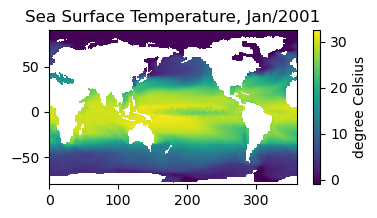

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# read TOS data
fp = './data/tos_200101.csv'
data = pd.read_csv(fp, sep=',')

# read data columns from pandas data frame into array vectors
lat_vec = data['lat'].values
lon_vec = data['lon'].values
tos_vec = data['tos_degC'].values

# set filling values to NaN
tos_vec[tos_vec==1e20] = np.nan

# reshape data vectors to matrices
lat = lat_vec.reshape(170,180)
lon = lon_vec.reshape(170,180)
tos = tos_vec.reshape(170,180)

# Print map for data grid using matplotlib
fig = plt.figure(figsize=(4, 2))
plt.pcolormesh(lon,lat, tos, shading='auto') 
plt.title("Sea Surface Temperature")
cbar = plt.colorbar()
cbar.set_label('degree Celsius')
plt.show()


#### Task 3.2
In a code cell below, create a mask for ocean regions of the northern hemisphere only. (You can perform this either with the originial data vectors or the reshaped matrices.)
Plot the mask, add a title, colorbar, and colorbar label. 
Also plot the masked data, add a title, colorbar, and colorbar label. 

#### Task 3.3
Next, calculate mean values of SST over the northern AND southern hemispheres. How can you calculate this for the southern hemisphere, without generating a second mask? Which function can you use, so that NaN values get ignored? 

Add a markdown cell below and neatly summarize your answers to these questions, your results, including explanatory text and a result overview, e.g., a table or similar.


In [9]:
# put your code to test the runtimes here


In [9]:
# put your code to test the runtimes here


In [ ]:
SUMMARIZE YOUR RESULTS HERE